In [1]:
# =========================================================================
# 1. TỰ ĐỘNG VÁ LỖI MÔI TRƯỜNG & KHAI BÁO HẠ TẦNG
# =========================================================================
import os
import sys
import subprocess

# Tự động cài đặt pyarrow để sửa triệt để lỗi "unit-less datetime64" của Pandas
try:
    import pyarrow
    print("-> Trạng thái: PyArrow đã sẵn sàng.")
except ImportError:
    print("-> Đang tự động cài đặt PyArrow để vá lỗi toPandas() cho các cell sau...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow", "-q"])
    print("-> Trạng thái: Cài đặt PyArrow thành công!")

os.environ["JAVA_HOME"] = r"D:\java\openjdk-8u482-b08"
os.environ["HADOOP_HOME"] = r"D:\java\hadoop-3.4.3"
os.environ["SPARK_HOME"] = r"D:\BIGDATA_G16\.venv\Lib\site-packages\pyspark"
os.environ["SPARK_LOCAL_DIRS"] = r"D:\BIGDATA_G16\Spark_Temp"

sys.path.append(r"D:\java\hadoop-3.4.3\bin")
sys.path.append(r"D:\BIGDATA_G16\.venv\Scripts")

# =========================================================================
# 2. KHỞI TẠO SPARK SESSION NỘI BỘ
# =========================================================================
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, IntegerType, TimestampType

try:
    SparkContext.getOrCreate().stop()
except Exception:
    pass

spark = SparkSession.builder \
    .appName("MetroPT3_MasterNode_Group16_EDA") \
    .master("local[*]") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "2g") \
    .config("spark.local.dir", r"D:\BIGDATA_G16\Spark_Temp") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("=== HỆ THỐNG SPARK ĐÃ KHỞI ĐỘNG ===")

# =========================================================================
# 3. ĐỌC VÀ CHUẨN HÓA DỮ LIỆU ĐÚNG NGUYÊN BẢN GỐC
# =========================================================================
hdfs_path = "hdfs://10.125.222.18:9000/Group16/MetroPT3(AirCompressor).csv"

print("-> Đang nạp dữ liệu siêu tốc từ HDFS...")
df_raw = spark.read.csv(hdfs_path, header=True, inferSchema=False)

# Phân loại danh sách cột chuẩn để ép kiểu
analog_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_electric', 'DV_eletric', 'TOWERS', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

print("-> Đang phục hồi chính xác kiểu dữ liệu gốc cho Dataset...")
# Dùng biến "df" làm gốc để các cell sau không bị NameError
df = df_raw
for c in df.columns:
    # So sánh không phân biệt hoa thường để quét chính xác mọi cột
    c_upper = c.upper()
    if c_upper in [x.upper() for x in analog_cols]:
        df = df.withColumn(c, col(c).cast(DoubleType()))
    elif c_upper in [x.upper() for x in digital_cols]:
        df = df.withColumn(c, col(c).cast(IntegerType()))
    elif c_upper == "TIMESTAMP":
        # Ép chuẩn cột thời gian để lúc toPandas() không bị văng lỗi
        df = df.withColumn(c, col(c).cast(TimestampType()))

# Tạo một "bí danh" df_clean trỏ ngược về df (Tránh NameError nếu code dưới lỡ gọi df_clean)
df_clean = df

# =========================================================================
# 4. KIỂM TRA SCHEMA
# =========================================================================
print("\n--- CẤU TRÚC KIỂU DỮ LIỆU ĐÃ SẴN SÀNG ---")
df.printSchema()
print("----------------------------------------------------------------")
print(f"-> Tổng số dòng dữ liệu: {df.count():,} dòng.")
print("----------------------------------------------------------------")

-> Đang tự động cài đặt PyArrow để vá lỗi toPandas() cho các cell sau...
-> Trạng thái: Cài đặt PyArrow thành công!
=== HỆ THỐNG SPARK ĐÃ KHỞI ĐỘNG ===
-> Đang nạp dữ liệu siêu tốc từ HDFS...
-> Đang phục hồi chính xác kiểu dữ liệu gốc cho Dataset...

--- CẤU TRÚC KIỂU DỮ LIỆU ĐÃ SẴN SÀNG ---
root
 |-- _c0: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: integer (nullable = true)
 |-- DV_eletric: integer (nullable = true)
 |-- Towers: integer (nullable = true)
 |-- MPG: integer (nullable = true)
 |-- LPS: integer (nullable = true)
 |-- Pressure_switch: integer (nullable = true)
 |-- Oil_level: integer (nullable = true)
 |-- Caudal_impulses: integer (nullable = true)

-----------

In [2]:
print("--- KIỂM TRA SCHEMA CỦA TẬP DỮ LIỆU SƠ CẤP ---")
df.printSchema()

--- KIỂM TRA SCHEMA CỦA TẬP DỮ LIỆU SƠ CẤP ---
root
 |-- _c0: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: integer (nullable = true)
 |-- DV_eletric: integer (nullable = true)
 |-- Towers: integer (nullable = true)
 |-- MPG: integer (nullable = true)
 |-- LPS: integer (nullable = true)
 |-- Pressure_switch: integer (nullable = true)
 |-- Oil_level: integer (nullable = true)
 |-- Caudal_impulses: integer (nullable = true)



In [3]:
analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
print("-> Trạng thái: Cụm Spark đang tính toán ma trận thống kê đầy đủ (bao gồm Q1, Median, Q3)...")
raw_summary = df.select(analog_cols).summary("min", "max", "mean", "stddev", "25%", "50%", "75%").toPandas()
summary_analog_df = raw_summary.set_index("summary").transpose().reset_index()
summary_analog_df.columns = ["Feature", "Min", "Max", "Mean", "Stddev", "Q1", "Median", "Q3"]
print("\n--- BẢNG KẾT QUẢ THỐNG KÊ MÔ TẢ ĐẦY ĐỦ CÁC CẢM BIẾN ANALOG ---")
summary_analog_df

-> Trạng thái: Cụm Spark đang tính toán ma trận thống kê đầy đủ (bao gồm Q1, Median, Q3)...

--- BẢNG KẾT QUẢ THỐNG KÊ MÔ TẢ ĐẦY ĐỦ CÁC CẢM BIẾN ANALOG ---


,Feature,Min,Max,Mean,Stddev,Q1,Median,Q3
0,TP2,-0.032,10.676,1.3678259663489785,3.2509296807037504,-0.0139999999999993,-0.0120000000000004,-0.009999999999998
1,TP3,0.7300000000000004,10.302,8.98461070122439,0.6390950863089495,8.492,8.96,9.492
2,H1,-0.0360000000000013,10.288,7.5681549004980555,3.333199565289423,8.254,8.784,9.374
3,DV_pressure,-0.032,9.844,0.05595618966494397,0.3824015460354255,-0.0219999999999984,-0.0199999999999995,-0.0180000000000006
4,Reservoirs,0.7119999999999997,10.3,8.985233443730726,0.6383070418596223,8.494,8.96,9.492
5,Oil_temperature,15.400000000000006,89.05000000000001,62.64418173860267,6.516261089444954,57.775000000000006,62.7,67.25000000000001
6,Motor_current,0.0199999999999995,9.295,2.0501708034835966,2.3020534138867563,0.04,0.0449999999999999,3.807500000000001


In [4]:
from pyspark.sql.functions import col, count, when, round
digital_cols = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]
print("-> Trạng thái: Cụm Spark đang tính toán tần suất phân bố cho các tín hiệu Digital...")
total_count = df.count()
exprs = []
for c in digital_cols:
    display_name = "DV_electric" if c == "DV_eletric" else c
    exprs.append(round((count(when(col(c) == '0.0', 1)) / total_count) * 100, 1).alias(f"{display_name}_%_0"))
    exprs.append(round((count(when(col(c) == '1.0', 1)) / total_count) * 100, 1).alias(f"{display_name}_%_1"))
summary_raw = df.select(exprs).collect()[0].asDict()
rows = []
for c in digital_cols:
    display_name = "DV_electric" if c == "DV_eletric" else c
    p0 = f"{summary_raw[f'{display_name}_%_0']}%"
    p1 = f"{summary_raw[f'{display_name}_%_1']}%"
    rows.append({
        "Tín hiệu": display_name,
        "% = 0": p0,
        "% = 1": p1
    })
import pandas as pd
summary_digital_df = pd.DataFrame(rows)

print("\n--- BẢNG KẾT QUẢ THỐNG KÊ TẦN SUẤT TÍN HIỆU DIGITAL TỪ HDFS ---")
summary_digital_df

-> Trạng thái: Cụm Spark đang tính toán tần suất phân bố cho các tín hiệu Digital...

--- BẢNG KẾT QUẢ THỐNG KÊ TẦN SUẤT TÍN HIỆU DIGITAL TỪ HDFS ---


,Tín hiệu,% = 0,% = 1
0,COMP,16.3%,83.7%
1,DV_electric,83.9%,16.1%
2,Towers,8.0%,92.0%
3,MPG,16.7%,83.3%
4,LPS,99.7%,0.3%
5,Pressure_switch,0.9%,99.1%
6,Oil_level,9.6%,90.4%
7,Caudal_impulses,6.3%,93.7%


In [5]:
from pyspark.sql.functions import col, count, when, isnan
import pandas as pd

print("-> Trạng thái: Cụm Spark đang truy vấn kiểm tra dữ liệu khuyết thiếu")
null_exprs = []
for c in df.columns:
    if c == "timestamp":
        null_exprs.append(count(when(col(c).isNull(), 1)).alias(c))
    else:
        null_exprs.append(count(when(col(c).isNull() | isnan(col(c).cast("double")), 1)).alias(c))

null_counts_dict = df.select(null_exprs).collect()[0].asDict()
missing_rows = []
for col_name, missing_count in null_counts_dict.items():
    display_name = "DV_electric" if col_name == "DV_eletric" else col_name
    percentage = (missing_count / 1516948) * 100

    missing_rows.append({
        "Thuộc tính": display_name,
        "Số dòng khuyết thiếu (Null/NaN)": missing_count,
        "Tỷ lệ (%)": f"{percentage:.3f}%",
    })

df_missing_summary = pd.DataFrame(missing_rows)

print("\n--- BẢNG KẾT QUẢ-")
df_missing_summary

-> Trạng thái: Cụm Spark đang truy vấn kiểm tra dữ liệu khuyết thiếu

--- BẢNG KẾT QUẢ-


,Thuộc tính,Số dòng khuyết thiếu (Null/NaN),Tỷ lệ (%)
0,_c0,0,0.000%
1,timestamp,0,0.000%
2,TP2,0,0.000%
3,TP3,0,0.000%
4,H1,0,0.000%
5,DV_pressure,0,0.000%
6,Reservoirs,0,0.000%
7,Oil_temperature,0,0.000%
8,Motor_current,0,0.000%
9,COMP,0,0.000%


In [6]:
total_raw_rows = df.count()
distinct_raw_rows = df.dropDuplicates().count()
duplicate_exist = total_raw_rows - distinct_raw_rows

print(f"-> Tổng số lượng bản ghi hiện có trong tập dữ liệu gốc: {total_raw_rows:,} dòng.")
print(f"-> Số lượng bản ghi định danh duy nhất (Distinct):     {distinct_raw_rows:,} dòng.")
print(f"-> Số lượng bản ghi trùng lặp tồn tại trong dữ liệu gốc: {duplicate_exist} dòng.")

-> Tổng số lượng bản ghi hiện có trong tập dữ liệu gốc: 1,516,948 dòng.
-> Số lượng bản ghi định danh duy nhất (Distinct):     1,516,948 dòng.
-> Số lượng bản ghi trùng lặp tồn tại trong dữ liệu gốc: 0 dòng.


In [7]:
from pyspark.sql.functions import col
import pandas as pd
import builtins

# 1. Định nghĩa hàm quét phân tán để đếm số lượng
def get_raw_outlier_pct(df_spark, column_name, q1, q3):
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Bộ lọc đếm số dòng nằm ngoài biên độ IQR của dữ liệu gốc
    outliers_count = df_spark.filter((col(column_name).cast("double") < lower_bound) |
                                     (col(column_name).cast("double") > upper_bound)).count()
    outlier_pct = (outliers_count / 1516948) * 100
    return builtins.round(outlier_pct, 1)

# 2. Khai báo các thông số Q1, Q3 thu thập từ ma trận thống kê mô tả sơ cấp
analog_specs = [
    {"Feature": "TP2", "Q1": -0.014, "Q3": -0.010, "Giải thích": "Trạng thái máy tắt / khởi động / Pre-Failure"},
    {"Feature": "TP3", "Q1": 8.492, "Q3": 9.492, "Giải thích": "Biến động áp suất panel khi chuyển trạng thái"},
    {"Feature": "H1", "Q1": 8.254, "Q3": 9.374, "Giải thích": "Đột biến khi bộ lọc cyclonic xả — sự kiện bình thường"},
    {"Feature": "DV_pressure", "Q1": -0.022, "Q3": -0.018, "Giải thích": "Tháp sấy xả ẩm — xảy ra định kỳ theo chu kỳ"},
    {"Feature": "Reservoirs", "Q1": 8.494, "Q3": 9.492, "Giải thích": "Áp suất bình tích khí chính biến động chu kỳ chạy tải"},
    {"Feature": "Oil_temperature", "Q1": 57.775, "Q3": 67.250, "Giải thích": "Máy vừa khởi động (thấp) hoặc quá nhiệt (cao)"},
    {"Feature": "Motor_current", "Q1": 0.040, "Q3": 3.808, "Giải thích": "Trạng thái tắt (~0A) hoặc vượt tải (>9A)"}
]

# 3. Tiến hành truy vấn song song và cấu trúc hóa bảng kết quả thống kê
outlier_rows = []
for spec in analog_specs:
    f_name = spec["Feature"]
    q1_val = spec["Q1"]
    q3_val = spec["Q3"]
    iqr_val = builtins.round(q3_val - q1_val, 3)

    pct_outlier = get_raw_outlier_pct(df, f_name, q1_val, q3_val)

    outlier_rows.append({
        "Feature": f_name,
        "Q1": q1_val,
        "Q3": q3_val,
        "IQR": iqr_val,
        "% Outlier gốc": f"~{pct_outlier}%",
        "Ý nghĩa kỹ thuật": spec["Giải thích"]
    })

df_outlier_summary = pd.DataFrame(outlier_rows)

print("\n--- BẢNG TỔNG HỢP ---")
df_outlier_summary


--- BẢNG TỔNG HỢP ---


,Feature,Q1,Q3,IQR,% Outlier gốc,Ý nghĩa kỹ thuật
0,TP2,-0.014,-0.010,0.004,~17.8%,Trạng thái máy tắt / khởi động / Pre-Failure
1,TP3,8.492,9.492,1.000,~0.3%,Biến động áp suất panel khi chuyển trạng thái
2,H1,8.254,9.374,1.120,~15.9%,Đột biến khi bộ lọc cyclonic xả — sự kiện bình...
3,DV_pressure,-0.022,-0.018,0.004,~5.6%,Tháp sấy xả ẩm — xảy ra định kỳ theo chu kỳ
4,Reservoirs,8.494,9.492,0.998,~0.3%,Áp suất bình tích khí chính biến động chu kỳ c...
5,Oil_temperature,57.775,67.250,9.475,~0.3%,Máy vừa khởi động (thấp) hoặc quá nhiệt (cao)
6,Motor_current,0.040,3.808,3.768,~0.0%,Trạng thái tắt (~0A) hoặc vượt tải (>9A)


In [8]:
# Import các hàm xử lý Spark cần thiết
from pyspark.sql.functions import col, to_timestamp, hour, month, dayofweek, avg, count
from pyspark.sql.types import IntegerType

# Định nghĩa danh sách thuộc tính dựa trên schema dữ liệu gốc của nhóm
analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
digital_cols = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]

In [9]:
# =========================================================================
# Ô CODE TỔNG HỢP: TIỀN XỬ LÝ (3.4) VÀ THỐNG KÊ CHUỖI THỜI GIAN (3.5)
# =========================================================================

from pyspark.sql.functions import col, to_timestamp, hour, month, dayofweek, avg, count
from pyspark.sql.types import IntegerType
import pandas as pd
import builtins

# -------------------------------------------------------------------------
# MỤC 3.4: TIỀN XỬ LÝ DỮ LIỆU
# -------------------------------------------------------------------------
df_clean = df.withColumn("timestamp", to_timestamp(col("timestamp"), "yyyy-MM-dd HH:mm:ss"))
df_clean = df_clean.withColumnRenamed("DV_eletric", "DV_electric")

digital_cols_clean = ["COMP", "DV_electric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]
for c in digital_cols_clean:
    df_clean = df_clean.withColumn(c, col(c).cast(IntegerType()))

df_clean = df_clean \
    .withColumn("hour", hour(col("timestamp"))) \
    .withColumn("month", month(col("timestamp"))) \
    .withColumn("dow", dayofweek(col("timestamp")))

# -------------------------------------------------------------------------
# MỤC 3.5.1: THỐNG KÊ CHUỖI THỜI GIAN THEO THÁNG
# -------------------------------------------------------------------------

monthly_summary = df_clean.groupBy("month").agg(
    count("*").alias("Số bản ghi"),
    avg("Motor_current").alias("Avg Motor"),
    avg("Oil_temperature").alias("Avg Oil_Temp"),
    avg("TP2").alias("Avg TP2")
).orderBy("month").collect()

monthly_rows = []
for row in monthly_summary:
    monthly_rows.append({
        "Tháng": f"Tháng {row['month']:02d}/2020",
        "Số bản ghi": f"{row['Số bản ghi']:,}",
        "Avg Motor (A)": builtins.round(row['Avg Motor'], 2),
        "Avg Oil_Temp (°C)": builtins.round(row['Avg Oil_Temp'], 1),
        "Avg TP2 (bar)": builtins.round(row['Avg TP2'], 2)
    })

df_monthly_report = pd.DataFrame(monthly_rows)


# -------------------------------------------------------------------------
# MỤC 3.5.2: THỐNG KÊ LƯỢNG DÒNG ĐIỆN TRUNG BÌNH THEO GIỜ
# -------------------------------------------------------------------------
hourly_summary = df_clean.groupBy("hour").agg(
    avg("Motor_current").alias("Avg_Motor_current")
).orderBy("hour").collect()

hourly_rows = []
for row in hourly_summary:
    h = row['hour']
    hourly_rows.append({
        "Khung giờ": f"{h:02d}:00 - {h:02d}:59",
        "Avg Motor_current (A)": f"{builtins.round(row['Avg_Motor_current'], 3)} A"
    })

df_hourly_report = pd.DataFrame(hourly_rows)

print("\n" + "="*70)
print("--- THỐNG KÊ CHUỖI THỜI GIAN THEO THÁNG ---")
print("="*70)
builtins.print(df_monthly_report.to_string(index=False))

print("\n" + "="*70)
print("--- THỐNG KÊ LƯỢNG DÒNG ĐIỆN TRUNG BÌNH THEO GIỜ ---")
print("="*70)
pd.set_option('display.max_rows', None)
builtins.print(df_hourly_report.to_string(index=False))


--- THỐNG KÊ CHUỖI THỜI GIAN THEO THÁNG ---
        Tháng Số bản ghi  Avg Motor (A)  Avg Oil_Temp (°C)  Avg TP2 (bar)
Tháng 02/2020    214,850           1.25               56.3           0.54
Tháng 03/2020    230,448           2.08               62.2           1.51
Tháng 04/2020    198,734           1.86               59.5           1.31
Tháng 05/2020    212,800           2.02               62.2           1.43
Tháng 06/2020    216,514           2.68               65.8           2.33
Tháng 07/2020    222,638           2.29               67.0           1.31
Tháng 08/2020    220,434           2.14               65.2           1.13
Tháng 09/2020        530           1.91               58.3           0.92

--- THỐNG KÊ LƯỢNG DÒNG ĐIỆN TRUNG BÌNH THEO GIỜ ---
    Khung giờ Avg Motor_current (A)
00:00 - 00:59               2.169 A
01:00 - 01:59               2.095 A
02:00 - 02:59               1.988 A
03:00 - 03:59               1.968 A
04:00 - 04:59               2.022 A
05:00 - 05:59      

In [10]:
HDFS_CLEAN_FOR_SQL = "hdfs://10.125.222.18:9000/user/bigdata/cleaned/metropt3_clean_for_sql"
df_clean.write.mode("overwrite").parquet(HDFS_CLEAN_FOR_SQL)

In [11]:
# =========================================================================
# TRÍCH XUẤT MỐC SỰ CỐ
# =========================================================================

from pyspark.sql import Window
from pyspark.sql.functions import col, lag, sum as _sum, min as _min, max as _max, unix_timestamp, date_format

try:
    # 1. Lọc các dòng có tín hiệu lỗi LPS = 1 và chuyển Timestamp sang số giây (Unix Time)
    df_lps = df_clean.filter(col("LPS") == 1).withColumn("time_secs", unix_timestamp(col("timestamp")))
    # Định nghĩa cấu trúc Window sắp xếp chuỗi thời gian tuyến tính tăng dần
    window_spec = Window.orderBy("time_secs")
    # Trích xuất mốc thời gian của dòng dữ liệu liền trước
    df_lps = df_lps.withColumn("prev_time_secs", lag("time_secs", 1).over(window_spec))
    # Thuật toán logic: Nếu khoảng cách dòng sau và dòng trước > 1 tiếng (3.600 giây) -> Đánh dấu 1 (Đợt lỗi mới)
    df_lps = df_lps.withColumn(
        "is_new_incident",
        (col("prev_time_secs").isNull() | ((col("time_secs") - col("prev_time_secs")) > 3600)).cast("int")
    )
    # Tạo số ID định danh tăng dần cho từng đợt sự cố bằng hàm cộng dồn tích lũy (Cumulative Sum)
    df_lps = df_lps.withColumn("incident_id", _sum("is_new_incident").over(window_spec))

    # 2. Gom nhóm (Aggregation) theo ID sự cố để tìm điểm Bắt đầu và Kết thúc của từng đợt
    df_final_log = df_lps.groupBy("incident_id").agg(
        _min("timestamp").alias("start_raw"),
        _max("timestamp").alias("end_raw")
    ).orderBy("incident_id")

    df_report = df_final_log.withColumn("Thời điểm bắt đầu", date_format(col("start_raw"), "yyyy-MM-dd HH:mm:ss")) \
                            .withColumn("Thời điểm kết thúc", date_format(col("end_raw"), "yyyy-MM-dd HH:mm:ss")) \
                            .select("incident_id", "Thời điểm bắt đầu", "Thời điểm kết thúc")

    pdf_result = df_report.toPandas()
    print(pdf_result.to_string(index=False))

except Exception as e:
    print(f"Lỗi thực thi hệ thống: {str(e)}")

 incident_id   Thời điểm bắt đầu  Thời điểm kết thúc
           1 2020-02-06 07:52:21 2020-02-06 07:52:21
           2 2020-03-11 19:21:55 2020-03-11 19:36:38
           3 2020-03-11 22:38:18 2020-03-11 22:47:43
           4 2020-03-12 12:04:12 2020-03-12 12:10:38
           5 2020-03-12 15:28:36 2020-03-12 16:47:52
           6 2020-03-14 06:29:10 2020-03-14 06:33:38
           7 2020-03-15 08:28:45 2020-03-15 08:30:24
           8 2020-03-15 23:25:28 2020-03-15 23:30:06
           9 2020-03-16 04:31:47 2020-03-16 04:35:05
          10 2020-03-20 06:25:41 2020-03-20 06:27:20
          11 2020-03-21 02:18:38 2020-03-21 02:19:17
          12 2020-03-24 04:03:08 2020-03-24 04:04:57
          13 2020-03-28 23:05:32 2020-03-28 23:28:11
          14 2020-03-30 07:33:30 2020-03-30 07:38:08
          15 2020-03-31 14:09:12 2020-03-31 14:10:12
          16 2020-04-04 02:32:23 2020-04-04 02:33:33
          17 2020-04-06 10:02:19 2020-04-06 10:05:17
          18 2020-04-06 14:20:48 2020-04-06 14

In [12]:
# =========================================================================
# XÂY DỰNG FAILURE EPISODES (TEMPORAL CONSOLIDATION)
# =========================================================================
from pyspark.sql.window import Window
from pyspark.sql.functions import col, lag, sum as _sum, min as _min, max as _max, unix_timestamp

window_episode = Window.orderBy("start_time_secs")
df_episodes_calc = df_final_log \
    .withColumn("start_time_secs", unix_timestamp(col("start_raw"))) \
    .withColumn("end_time_secs", unix_timestamp(col("end_raw")))

# Trích xuất mốc kết thúc của incident liền trước để đo đạc khoảng đệm phục hồi hệ thống
df_episodes_calc = df_episodes_calc.withColumn("prev_end_raw_secs", lag("end_time_secs", 1).over(window_episode))
# Thiết lập ngưỡng ngắt quãng kỹ thuật là 5 ngày (432.000 giây) để xác định đợt lỗi độc lập
NGUONG_GOP_5_NGAY = 5 * 24 * 60 * 60
# Thuật toán: Nếu 2 incident cách nhau dưới 5 ngày -> Cùng một vết rò rỉ rải rác chưa sửa xong -> Gộp cụm
df_episodes_calc = df_episodes_calc.withColumn(
    "is_new_episode",
    (col("prev_end_raw_secs").isNull() | ((col("start_time_secs") - col("prev_end_raw_secs")) > NGUONG_GOP_5_NGAY)).cast("int")
)
# Tạo ID định danh tăng dần cho các cụm sự cố lớn bằng hàm cộng dồn lũy tiến
df_episodes_calc = df_episodes_calc.withColumn("episode_id", _sum("is_new_episode").over(window_episode))
# Gom nhóm (Aggregation) để thu hoạch điểm Bắt đầu và Kết thúc chuẩn của các Failure Episodes hệ thống
df_failure_episodes = df_episodes_calc.groupBy("episode_id").agg(
    _min("start_raw").alias("episode_start"),
    _max("end_raw").alias("episode_end")
).orderBy("episode_id")
# Tính toán lùi lại đúng 24 giờ trước 'episode_start' để làm mốc bắt đầu Cửa sổ Tiền sự cố
df_episodes_with_windows = df_failure_episodes.withColumn(
    "pre_failure_start",
    (unix_timestamp(col("episode_start")) - (24 * 60 * 60)).cast("timestamp")
)
failure_windows_list = df_episodes_with_windows.collect()
df_episodes_with_windows.select("episode_id", "pre_failure_start", "episode_start", "episode_end").show(truncate=False)

+----------+-------------------+-------------------+-------------------+
|episode_id|pre_failure_start  |episode_start      |episode_end        |
+----------+-------------------+-------------------+-------------------+
|1         |2020-02-05 07:52:21|2020-02-06 07:52:21|2020-02-06 07:52:21|
|2         |2020-03-10 19:21:55|2020-03-11 19:21:55|2020-06-22 02:45:40|
|3         |2020-06-27 23:07:43|2020-06-28 23:07:43|2020-06-28 23:15:08|
|4         |2020-07-05 15:26:55|2020-07-06 15:26:55|2020-07-17 07:34:50|
|5         |2020-07-23 01:00:31|2020-07-24 01:00:31|2020-08-26 00:58:24|
|6         |2020-08-31 00:37:33|2020-09-01 00:37:33|2020-09-01 00:38:02|
+----------+-------------------+-------------------+-------------------+



In [31]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, TimestampType
from pyspark.sql.window import Window
import pyspark

cleaned_windows_list = [
    {
        "episode_start": row['episode_start'],
        "episode_end": row['episode_end'],
        "pre_failure_start": row['pre_failure_start']
    }
    for row in failure_windows_list
]

schema = StructType([
    StructField("episode_start", TimestampType(), True),
    StructField("episode_end", TimestampType(), True),
    StructField("pre_failure_start", TimestampType(), True)
])

windows_df = spark.createDataFrame(cleaned_windows_list, schema)
join_condition = (F.col("timestamp") >= F.col("pre_failure_start")) & (F.col("timestamp") <= F.col("episode_end"))
df_joined = df_clean.join(F.broadcast(windows_df), join_condition, "left")

df_priority = df_joined.withColumn("label_priority",
    F.when((F.col("timestamp") >= F.col("episode_start")) & (F.col("timestamp") <= F.col("episode_end")), F.lit(2))
     .when((F.col("timestamp") >= F.col("pre_failure_start")) & (F.col("timestamp") < F.col("episode_start")), F.lit(1))
     .otherwise(F.lit(0))
)

window_spec = Window.partitionBy("timestamp")
df_max_priority = df_priority.withColumn("final_priority", F.max("label_priority").over(window_spec))

df_final = df_max_priority.dropDuplicates(["timestamp"]) \
    .withColumn("Pre_Failure",
        F.when(F.col("final_priority") == 2, F.lit(None))
         .when(F.col("final_priority") == 1, F.lit(1))
         .otherwise(F.lit(0))
    )

df_final_training = df_final.filter(F.col("Pre_Failure").isNotNull()) \
                            .drop("label_priority", "final_priority", "episode_start", "episode_end", "pre_failure_start", "is_failure", "is_pre_failure")

df_final_training.persist(pyspark.StorageLevel.MEMORY_AND_DISK)

total_records = df_final_training.count()
df_distribution = df_final_training.groupBy("Pre_Failure").agg(
    F.count("*").alias("Số bản ghi"),
    F.round((F.count("*") / total_records) * 100, 2).alias("Tỷ lệ (%)")
).orderBy("Pre_Failure")

df_distribution.show()
df_final_training.explain(extended=False)

+-----------+----------+---------+
|Pre_Failure|Số bản ghi|Tỷ lệ (%)|
+-----------+----------+---------+
|          0|    467353|    93.52|
|          1|     32393|     6.48|
+-----------+----------+---------+

== Physical Plan ==
InMemoryTableScan [_c0#17, timestamp#1862, TP2#70, TP3#88, H1#106, DV_pressure#124, Reservoirs#142, Oil_temperature#160, Motor_current#178, COMP#1898, DV_electric#1916, Towers#1934, MPG#1952, LPS#1970, Pressure_switch#1988, Oil_level#2006, Caudal_impulses#2024, hour#2042, month#2061, dow#2081, Pre_Failure#12507]
   +- InMemoryRelation [_c0#17, timestamp#1862, TP2#70, TP3#88, H1#106, DV_pressure#124, Reservoirs#142, Oil_temperature#160, Motor_current#178, COMP#1898, DV_electric#1916, Towers#1934, MPG#1952, LPS#1970, Pressure_switch#1988, Oil_level#2006, Caudal_impulses#2024, hour#2042, month#2061, dow#2081, Pre_Failure#12507], StorageLevel(disk, memory, 1 replicas)
         +- *(5) Project [_c0#12556, timestamp#1862, TP2#12558, TP3#12560, H1#12562, DV_pressure

In [32]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd

# 1. Khai báo các cột cần tính tương quan
valid_analog_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

# 2. DÙNG MLLIB: Gom các cột thành 1 Vector duy nhất
assembler = VectorAssembler(inputCols=valid_analog_cols, outputCol="features")
df_vector = assembler.transform(df_clean).select("features")

# 3. DÙNG MLLIB: Tính ma trận tương quan chỉ bằng
# Nó sẽ tính toán toàn bộ các cặp cùng một lúc trên Cluster
pearson_corr = Correlation.corr(df_vector, "features", "pearson").head()

# 4. Trích xuất kết quả ma trận và đưa về dạng Pandas để hiển thị cho đẹp
corr_matrix = pearson_corr[0].toArray()

# Hiển thị trực quan cho báo cáo
df_corr_matrix = pd.DataFrame(corr_matrix, index=valid_analog_cols, columns=valid_analog_cols)

print("--- BẢNG MA TRẬN TƯƠNG QUAN PEARSON ---")
display(df_corr_matrix.round(4)) if 'display' in globals() else print(df_corr_matrix.round(4))

--- BẢNG MA TRẬN TƯƠNG QUAN PEARSON ---
                    TP2     TP3      H1  DV_pressure  Reservoirs  \
TP2              1.0000 -0.0112 -0.9613       0.4150     -0.0124   
TP3             -0.0112  1.0000  0.2249      -0.1531      1.0000   
H1              -0.9613  0.2249  1.0000      -0.4255      0.2260   
DV_pressure      0.4150 -0.1531 -0.4255       1.0000     -0.1531   
Reservoirs      -0.0124  1.0000  0.2260      -0.1531      1.0000   
Oil_temperature  0.2507  0.4016 -0.1618       0.3397      0.4016   
Motor_current    0.6975  0.4138 -0.6002       0.3022      0.4127   

                 Oil_temperature  Motor_current  
TP2                       0.2507         0.6975  
TP3                       0.4016         0.4138  
H1                       -0.1618        -0.6002  
DV_pressure               0.3397         0.3022  
Reservoirs                0.4016         0.4127  
Oil_temperature           1.0000         0.5287  
Motor_current             0.5287         1.0000  


In [33]:
from pyspark.sql import functions as F

digital_cols = ["COMP", "MPG", "Towers", "LPS", "Pressure_switch", "Oil_level", "DV_electric", "Caudal_impulses"]

exprs = [F.avg(c).alias(c) for c in digital_cols]

avg_results = df_final_training.select(*exprs).collect()[0].asDict()

print(f"{'Digital Signal':<25}{'Dominant Ratio (%)':<25}")
print("-" * 50)

for c, ratio_of_1 in avg_results.items():
    if ratio_of_1 is None:
        print(f"{c:<25}{'NULL':<25}")
        continue

    dominant_ratio = max(ratio_of_1, 1 - ratio_of_1) * 100
    print(f"{c:<25}{dominant_ratio:<25.2f}")

Digital Signal           Dominant Ratio (%)       
--------------------------------------------------
COMP                     86.53                    
MPG                      86.21                    
Towers                   94.27                    
LPS                      100.00                   
Pressure_switch          98.89                    
Oil_level                98.05                    
DV_electric              87.13                    
Caudal_impulses          83.01                    


In [34]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import pandas as pd
import numpy as np
from scipy import stats
import builtins

analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
features_eval = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current",
                 "COMP", "DV_electric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]

df_sample = df_final_training.sample(withReplacement=False, fraction=0.1, seed=42).toPandas()
results_list = []
target = df_sample["Pre_Failure"].values
for f in features_eval:
    feat_values = df_sample[f].values

    if f in analog_cols:
        r_val, p_val = stats.pointbiserialr(feat_values, target)
        method = "Point-Biserial"
    else:
        ct = pd.crosstab(feat_values, target)
        if ct.shape == (2, 2):
            chi2, p_val, _, _ = stats.chi2_contingency(ct)
            phi_val = np.sqrt(chi2 / ct.sum().sum())
            r_val = phi_val
        else:
            r_val, p_val = 0.0, 1.0
        method = "Phi Coefficient"
    results_list.append({
        "Feature": f,
        "Method": method,
        "Score": builtins.round(float(abs(r_val)), 4),
        "p-value": float(p_val)
    })

df_res = pd.DataFrame(results_list).sort_values(by="Score", ascending=False)
print(df_res.to_string(index=False))

        Feature          Method  Score       p-value
Oil_temperature  Point-Biserial 0.1149 3.130475e-147
      Oil_level Phi Coefficient 0.0306  7.061061e-12
    DV_pressure  Point-Biserial 0.0194  1.307797e-05
  Motor_current  Point-Biserial 0.0192  1.641371e-05
Pressure_switch Phi Coefficient 0.0178  6.570353e-05
            TP3  Point-Biserial 0.0131  3.387465e-03
     Reservoirs  Point-Biserial 0.0131  3.382503e-03
Caudal_impulses Phi Coefficient 0.0122  6.216327e-03
            MPG Phi Coefficient 0.0086  5.395584e-02
           COMP Phi Coefficient 0.0083  6.170979e-02
         Towers Phi Coefficient 0.0076  8.921369e-02
             H1  Point-Biserial 0.0067  1.338842e-01
            TP2  Point-Biserial 0.0041  3.593943e-01
    DV_electric Phi Coefficient 0.0021  6.299459e-01
            LPS Phi Coefficient 0.0000  1.000000e+00


In [39]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]

df_sample = df_final_training.sample(withReplacement=False, fraction=0.1, seed=42).toPandas()
valid_cols = [c for c in analog_cols if c in df_sample.columns]

X = df_sample[valid_cols].dropna()
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print(vif_data.to_string(index=False))

        Feature          VIF
            TP3 61044.749863
     Reservoirs 60951.695960
             H1    52.896307
            TP2    48.909133
  Motor_current     3.617659
Oil_temperature     1.361083
    DV_pressure     1.073431


In [41]:
from pyspark.sql import functions as F
from scipy import stats

df_with_delta = df_final_training.withColumn("pressure_delta", F.col("TP3") - F.col("TP2"))

df_final_engineered = df_with_delta.drop("TP3", "Reservoirs")

pdf = df_final_engineered.select("pressure_delta", "Pre_Failure") \
                         .sample(withReplacement=False, fraction=0.1, seed=42) \
                         .toPandas()

r_val, p_val = stats.pointbiserialr(pdf["pressure_delta"].values, pdf["Pre_Failure"].values)

print(f"Hệ số tương quan của pressure_delta với Pre_Failure: {abs(r_val):.4f}")
print(f"p-value: {p_val:.4e}")

Hệ số tương quan của pressure_delta với Pre_Failure: 0.0065
p-value: 1.4658e-01



--- Bảng độ quan trọng của các đặc trưng (RF Importance) ---
        Feature  RF_Importance
Oil_temperature       0.304060
    DV_pressure       0.168682
  Motor_current       0.120341
            TP2       0.116754
             H1       0.103294
 pressure_delta       0.070830
      Oil_level       0.050776
           COMP       0.021678
    DV_electric       0.012555
            MPG       0.009879
Caudal_impulses       0.008731
         Towers       0.007873
Pressure_switch       0.004549
            LPS       0.000000


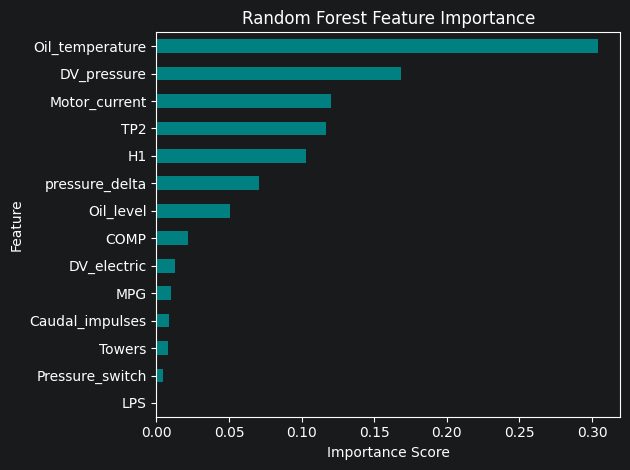

In [42]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
# 1. Danh sách các đặc trưng chuẩn sau khi đã loại bỏ TP3 và Reservoirs
feature_cols = ["TP2", "H1", "DV_pressure", "Oil_temperature", "Motor_current", "pressure_delta",
                "COMP", "DV_electric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]
# 2. Đóng gói các cột đặc trưng thành 1 Vector đầu vào duy nhất cho MLlib
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_rf = assembler.transform(df_final_engineered).select("features", "Pre_Failure")

# 3. Huấn luyện mô hình Random Forest phân tán trên Cluster
rf = RandomForestClassifier(featuresCol="features", labelCol="Pre_Failure",
                            numTrees=50, maxDepth=5, seed=42)
model = rf.fit(df_rf.sample(fraction=0.1, seed=42))
# 4. Trích xuất mức độ đóng góp (Feature Importance) của từng cảm biến
importances = model.featureImportances.toArray()
df_importance = pd.DataFrame({"Feature": feature_cols, "RF_Importance": importances})
df_importance = df_importance.sort_values(by="RF_Importance", ascending=False)
# 5. Xuất kết quả dạng bảng text và vẽ biểu đồ trực quan
print("\n--- Bảng độ quan trọng của các đặc trưng (RF Importance) ---")
print(df_importance.to_string(index=False))
df_importance.sort_values(by="RF_Importance", ascending=True).plot(
    kind='barh', x='Feature', y='RF_Importance', legend=False, color='teal'
)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [43]:
# 1. Khai báo đường dẫn lưu trữ trên cụm HDFS phân tán
HDFS_CLEAN = "hdfs://10.125.222.18:9000/user/bigdata/cleaned/metropt3_cleaned"
HDFS_ML    = "hdfs://10.125.222.18:9000/user/bigdata/cleaned/metropt3_ml_ready"

# 2. Thực thi ghi dữ liệu phân tán dưới định dạng nén Parquet
df_clean.write.mode("overwrite").parquet(HDFS_CLEAN)
df_final_engineered.write.mode("overwrite").parquet(HDFS_ML)
df_clean.createOrReplaceTempView("metropt_raw")
df_final_engineered.createOrReplaceTempView("metropt")

print("Đã lưu trữ thành công dữ liệu sạch và dữ liệu huấn luyện lên HDFS!")

Đã lưu trữ thành công dữ liệu sạch và dữ liệu huấn luyện lên HDFS!
